In [53]:
import pandas as pd 
import numpy as np
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from scipy import stats
from scipy.stats import mannwhitneyu

In [54]:
pd.read_excel("eval.xlsx").to_csv("eval.csv", index=False)


In [55]:
eval_bio = pd.read_csv('vg_rag_cot_evaluated_2.tsv', sep = '\t')[['submitter_id','comprehensiveness','factual_consistency','risk_integration','clinical_relevance']]
eval_base_template = pd.read_csv('evaluation_results_baseline_template.csv')
eval_base_open = pd.read_csv('evaluation_results_baseline_openllm.csv')
eval_base_gpt = pd.read_csv('evaluation_results_baseline_gpt.csv')
eval_bio = eval_bio.rename(columns = {'comprehensiveness':'Comprehensiveness',
                                      'factual_consistency':'Factual Consistency',
                                     'risk_integration':'Risk Integration','clinical_relevance':'Clinical Relevance'})

In [56]:
eval_bio

,submitter_id,Comprehensiveness,Factual Consistency,Risk Integration,Clinical Relevance
0,TCGA-E9-A5FL,4,3,4,2
1,TCGA-AN-A0XO,4,4,4,3
2,TCGA-AR-A0TX,4,4,4,4
3,TCGA-B6-A0IH,4,3,4,3
4,TCGA-D8-A1XC,5,5,4,4
...,...,...,...,...,...
1017,TCGA-BH-A1FC,4,4,4,3
1018,TCGA-BH-A204,4,4,3,3
1019,TCGA-BH-A208,4,4,4,3
1020,TCGA-A8-A08R,4,4,4,3


In [57]:
eval_base_gpt

,submitter_id,risk_check,feature_score,judge
0,TCGA-E9-A5FL,1,1.0,"{'Comprehensiveness': 3, 'Factual Consistency'..."
1,TCGA-AN-A0XO,1,1.0,"{'Comprehensiveness': 3, 'Factual Consistency'..."
2,TCGA-AR-A0TX,1,1.0,"{'Comprehensiveness': 3, 'Factual Consistency'..."
3,TCGA-B6-A0IH,1,1.0,"{'Comprehensiveness': 4, 'Factual Consistency'..."
4,TCGA-D8-A1XC,1,1.0,"{'Comprehensiveness': 4, 'Factual Consistency'..."
...,...,...,...,...
1017,TCGA-BH-A1FC,1,1.0,"{'Comprehensiveness': 4, 'Factual Consistency'..."
1018,TCGA-BH-A204,1,1.0,"{'Comprehensiveness': 3, 'Factual Consistency'..."
1019,TCGA-BH-A208,1,1.0,"{'Comprehensiveness': 4, 'Factual Consistency'..."
1020,TCGA-A8-A08R,0,1.0,"{'Comprehensiveness': 2, 'Factual Consistency'..."


In [58]:
import ast

def format_transfer(eval_base_template):
    eval_base_template["judge"] = eval_base_template["judge"].apply(ast.literal_eval)
    judge_df = eval_base_template['judge'].apply(pd.Series)
    eval_base_template = pd.concat([eval_base_template[['submitter_id']], judge_df], axis=1)
    return eval_base_template

eval_base_template = format_transfer(eval_base_template)
eval_base_open = format_transfer(eval_base_open)
eval_base_gpt = format_transfer(eval_base_gpt)

In [59]:
eval_bio['model'] = 'Proposed'
eval_base_template['model'] = 'Template_Based'
eval_base_open['model'] = 'openbioLLM-8B'
eval_base_gpt['model'] = 'GPT-5.4-mini'

In [60]:
df_all = pd.concat([eval_bio, eval_base_template, eval_base_open, eval_base_gpt], axis=0)
df_long = df_all.melt(
    id_vars=['submitter_id', 'model'],
    var_name='dimension',
    value_name='score'
)

In [61]:
df_long

,submitter_id,model,dimension,score
0,TCGA-E9-A5FL,Proposed,Comprehensiveness,4
1,TCGA-AN-A0XO,Proposed,Comprehensiveness,4
2,TCGA-AR-A0TX,Proposed,Comprehensiveness,4
3,TCGA-B6-A0IH,Proposed,Comprehensiveness,4
4,TCGA-D8-A1XC,Proposed,Comprehensiveness,5
...,...,...,...,...
16347,TCGA-BH-A1FC,GPT-5.4-mini,Clinical Relevance,2
16348,TCGA-BH-A204,GPT-5.4-mini,Clinical Relevance,2
16349,TCGA-BH-A208,GPT-5.4-mini,Clinical Relevance,2
16350,TCGA-A8-A08R,GPT-5.4-mini,Clinical Relevance,1


In [62]:
#pip install statannotations

In [63]:
from scipy.stats import wilcoxon
import pandas as pd
from statsmodels.stats.multitest import multipletests

results = []

dimensions = df_long["dimension"].unique()

for dim in dimensions:
    sub = df_long[df_long["dimension"] == dim]

    # pivot so rows align by submitter_id (IMPORTANT for paired test)
    pivot = sub.pivot(index="submitter_id", columns="model", values="score")

    for baseline in ["Template_Based", "openbioLLM-8B", "GPT-5.4-mini"]:
        x = pivot["Proposed"]
        y = pivot[baseline]

        # drop NA pairs just in case
        valid = x.notna() & y.notna()

        stat, p = wilcoxon(x[valid], y[valid])

        results.append({
            "dimension": dim,
            "comparison": f"Proposed vs {baseline}",
            "p_value": p
        })

pval_df = pd.DataFrame(results)

pval_df["p_adj"] = multipletests(
    pval_df["p_value"],
    method="fdr_bh"
)[1]


pval_df["p_value_formatted"] = pval_df["p_value"].apply(lambda x: f"{x:.3g}")


print(pval_df)

              dimension                  comparison        p_value  \
0     Comprehensiveness  Proposed vs Template_Based  4.817641e-158   
1     Comprehensiveness   Proposed vs openbioLLM-8B  1.306655e-156   
2     Comprehensiveness    Proposed vs GPT-5.4-mini  7.386819e-170   
3   Factual Consistency  Proposed vs Template_Based  2.926171e-178   
4   Factual Consistency   Proposed vs openbioLLM-8B  1.440204e-109   
5   Factual Consistency    Proposed vs GPT-5.4-mini  8.440291e-168   
6      Risk Integration  Proposed vs Template_Based  1.185450e-159   
7      Risk Integration   Proposed vs openbioLLM-8B  6.356650e-172   
8      Risk Integration    Proposed vs GPT-5.4-mini  3.915620e-158   
9    Clinical Relevance  Proposed vs Template_Based  1.059661e-165   
10   Clinical Relevance   Proposed vs openbioLLM-8B  4.872782e-146   
11   Clinical Relevance    Proposed vs GPT-5.4-mini  1.977769e-159   

            p_adj p_value_formatted  
0   6.423522e-158         4.82e-158  
1   1.567986e

/tmp/ipykernel_2356490/3770733620.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


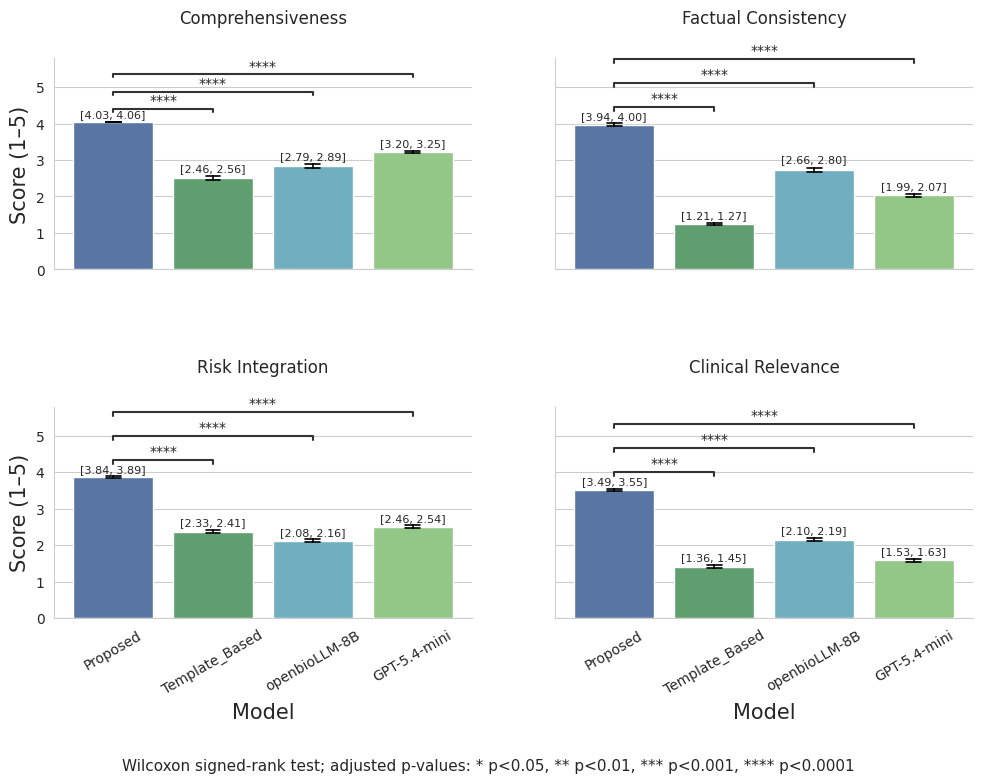

In [64]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

sns.set_style("whitegrid")

model_order = ["Proposed", "Template_Based", "openbioLLM-8B", "GPT-5.4-mini"]

dimensions = [
    "Comprehensiveness",
    "Factual Consistency",
    "Risk Integration",
    "Clinical Relevance"
]



palette = {
    "Proposed": "#4C72B0",
    "Template_Based": "#55A868",
    "openbioLLM-8B": "#64B5CD",
    "GPT-5.4-mini": "#8CD17D"
}

pairs = [
    ("Proposed", "Template_Based"),
    ("Proposed", "openbioLLM-8B"),
    ("Proposed", "GPT-5.4-mini")
]

def bootstrap_ci(data, n_boot=2000, seed=0):
    data = np.asarray(data.dropna(), dtype=float)
    rng = np.random.default_rng(seed)

    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means.append(sample.mean())

    lower, upper = np.percentile(boot_means, [2.5, 97.5])
    return lower, upper

g = sns.catplot(
    data=df_long,
    x="model",
    y="score",
    palette=palette,
    col="dimension",
    col_order=dimensions,
    kind="bar",
    order=model_order,
    errorbar=("ci", 95),
    n_boot=2000,
    capsize=0.15,
    err_kws={"color": "black", "linewidth": 1.2},
    sharey=True,
    height=4,
    aspect=1.25,
    col_wrap=2
)

for ax, dim in zip(g.axes.flat, dimensions):
    sub_df = df_long[df_long["dimension"] == dim]

    # Add adjusted p-values from pval_df
    pvalues_adj = (
        pval_df[pval_df["dimension"] == dim]
        .set_index("comparison")
        .loc[[f"{m1} vs {m2}" for m1, m2 in pairs], "p_adj"]
        .tolist()
    )

    annotator = Annotator(
        ax,
        pairs,
        data=sub_df,
        x="model",
        y="score",
        order=model_order
    )

    annotator.configure(
        text_format="star",
        loc="inside",
        verbose=0
    )

    annotator.set_pvalues_and_annotate(pvalues_adj)

    # Add CI annotation above each error bar
    for i, model in enumerate(model_order):
        vals = sub_df[sub_df["model"] == model]["score"]
        lower, upper = bootstrap_ci(vals, n_boot=2000, seed=0)

        ax.text(
            i,
            upper + 0.07,
            f"[{lower:.2f}, {upper:.2f}]",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(dim, pad=25)
    ax.set_xlabel("Model", fontsize=15)
    ax.set_ylabel("Score (1–5)", fontsize=15)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 5.8)

g.fig.subplots_adjust(top=0.90, hspace=0.65, wspace=0.20)

g.fig.text(
    0.5, 0.01,
    "Wilcoxon signed-rank test; adjusted p-values: * p<0.05, ** p<0.01, *** p<0.001, **** p<0.0001",
    ha="center",
    fontsize=11
)

g.fig.subplots_adjust(bottom=0.20)

plt.show()

/tmp/ipykernel_2356490/1488554655.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


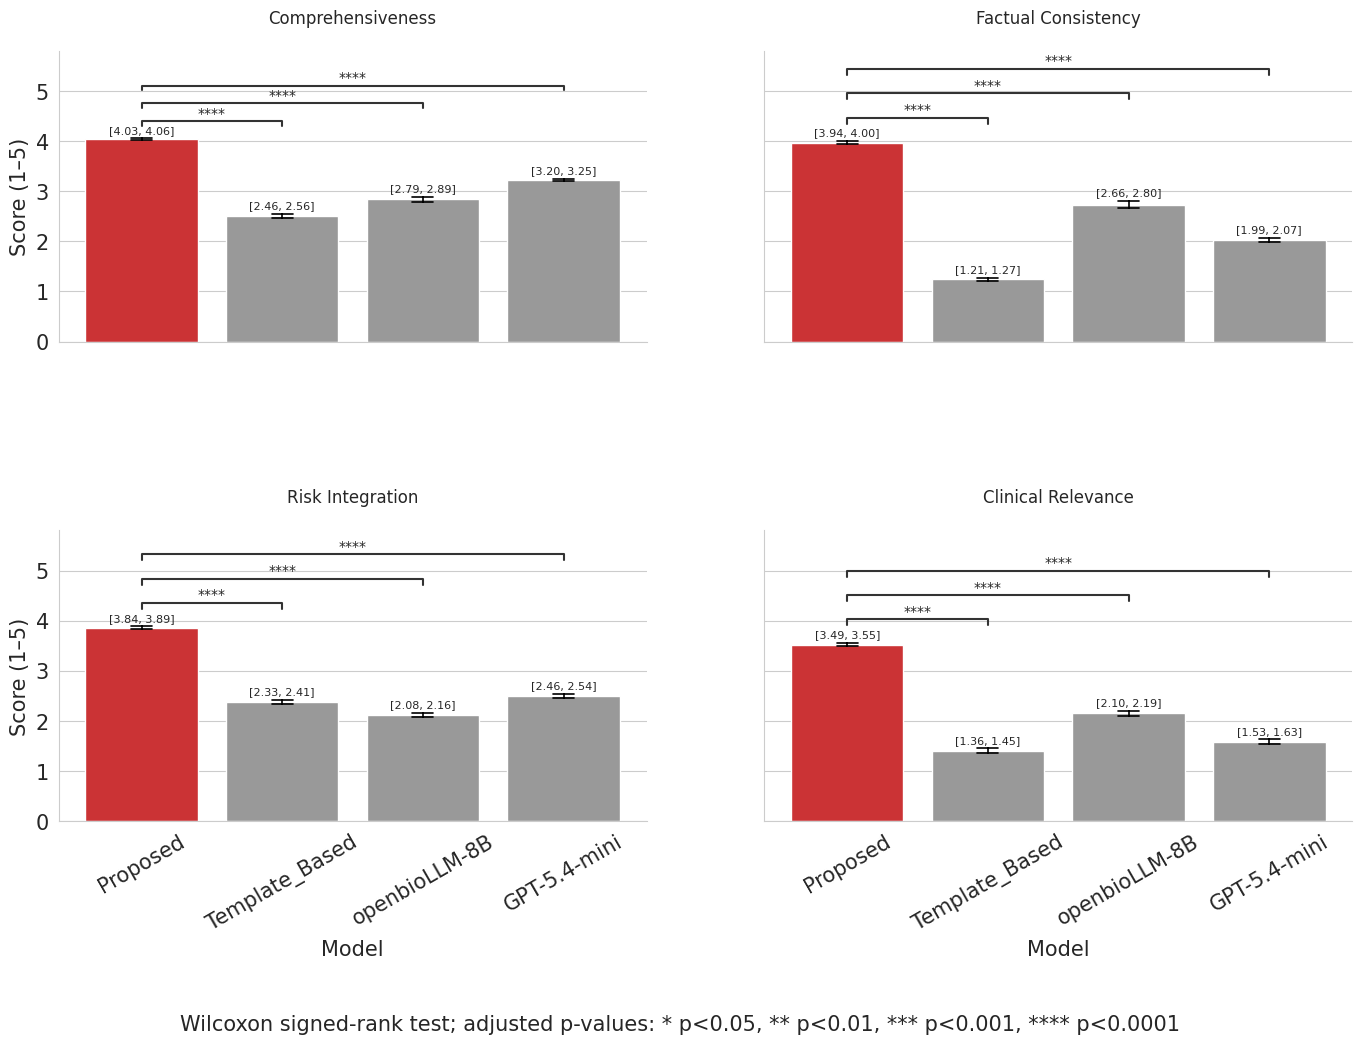

In [65]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

sns.set_style("whitegrid")

model_order = ["Proposed", "Template_Based", "openbioLLM-8B", "GPT-5.4-mini"]

dimensions = [
    "Comprehensiveness",
    "Factual Consistency",
    "Risk Integration",
    "Clinical Relevance"
]



palette = {
    "Proposed": "#E41A1C",
    "Template_Based": "#999999",
    "openbioLLM-8B": "#999999",
    "GPT-5.4-mini": "#999999"
}

pairs = [
    ("Proposed", "Template_Based"),
    ("Proposed", "openbioLLM-8B"),
    ("Proposed", "GPT-5.4-mini")
]

def bootstrap_ci(data, n_boot=2000, seed=0):
    data = np.asarray(data.dropna(), dtype=float)
    rng = np.random.default_rng(seed)

    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means.append(sample.mean())

    lower, upper = np.percentile(boot_means, [2.5, 97.5])
    return lower, upper

g = sns.catplot(
    data=df_long,
    x="model",
    y="score",
    palette=palette,
    col="dimension",
    col_order=dimensions,
    kind="bar",
    order=model_order,
    errorbar=("ci", 95),
    n_boot=2000,
    capsize=0.15,
    err_kws={"color": "black", "linewidth": 1.2},
    sharey=True,
    height=5.5,
    aspect=1.25,
    col_wrap=2
)

for ax, dim in zip(g.axes.flat, dimensions):
    sub_df = df_long[df_long["dimension"] == dim]

    # Add adjusted p-values from pval_df
    pvalues_adj = (
        pval_df[pval_df["dimension"] == dim]
        .set_index("comparison")
        .loc[[f"{m1} vs {m2}" for m1, m2 in pairs], "p_adj"]
        .tolist()
    )

    annotator = Annotator(
        ax,
        pairs,
        data=sub_df,
        x="model",
        y="score",
        order=model_order
    )

    annotator.configure(
        text_format="star",
        loc="inside",
        verbose=0
    )

    annotator.set_pvalues_and_annotate(pvalues_adj)

    # Add CI annotation above each error bar
    for i, model in enumerate(model_order):
        vals = sub_df[sub_df["model"] == model]["score"]
        lower, upper = bootstrap_ci(vals, n_boot=2000, seed=0)

        ax.text(
            i,
            upper + 0.07,
            f"[{lower:.2f}, {upper:.2f}]",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(dim, pad=20)
    ax.set_xlabel("Model", fontsize=15)
    ax.set_ylabel("Score (1–5)", fontsize=15)
    ax.tick_params(axis="x", labelsize=15)
    ax.tick_params(axis="y", labelsize=15)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 5.8)

g.fig.subplots_adjust(top=0.90, hspace=0.65, wspace=0.20)

g.fig.text(
    0.5, 0.01,
    "Wilcoxon signed-rank test; adjusted p-values: * p<0.05, ** p<0.01, *** p<0.001, **** p<0.0001",
    ha="center",
    fontsize=15
)

g.fig.subplots_adjust(bottom=0.20)
plt.savefig('barplot.png')
plt.show()


In [66]:
heatmap_df = (
    df_long
    .groupby(["model", "dimension"])["score"]
    .mean()
    .unstack()
)

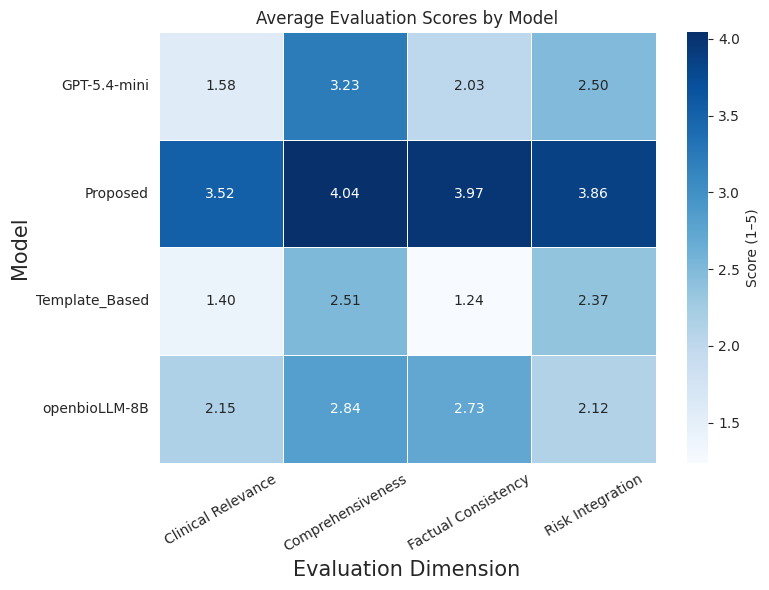

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_df,
    annot=True,          # show numbers
    fmt=".2f",
    cmap="Blues",        # 👈 blue theme
    linewidths=0.5,
    cbar_kws={"label": "Score (1–5)"}
)

plt.ylabel("Model",fontsize = 15)
plt.xlabel("Evaluation Dimension",fontsize = 15)
plt.title("Average Evaluation Scores by Model")
plt.yticks(rotation = 360)
plt.xticks(rotation = 30)
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()
